# Calibrator wavefront PCA

PCA of the primary wavefronts and amplitudes recovered by `batch/calibrator-joint.py`, plus the distributions of the other fitted parameters.

The high-order wavefront (`primary_opd`, a 45x45 Fourier basis) is fitted alongside per-exposure low-order Zernikes (`primary_low`, Noll 4-33) and tilts, so any part of it lying in the span of Noll 1-33 is degenerate with them. That part is projected out before the PCA.

In [227]:
import sys
sys.path.insert(0, '..')

In [228]:
# Basic imports
import jax.numpy as np
import jax
import numpy

jax.config.update("jax_enable_x64", True)

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
import matplotlib.pyplot as plt
import matplotlib

from sklearn.decomposition import PCA
from glob import glob

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from apertures import *
from models import *

## Load the fits

In [229]:
# Fits may still be running or partly downloaded: keep only runs whose params and diagnostics both load
runs, params, diags = [], [], []
for f in sorted(glob("../batch/calibrator-joint/*/params_amp.npy"), key=lambda f: int(f.split("/")[-2].split("-")[0])):
    try:
        # Stage-2 params only hold the parameters fitted in stage 2; the rest (e.g. cold_mask_shear, primary_shear,
        # primary_outer) keep their stage-1 values, saved in intermediate-params.npy
        p = numpy.load(f.replace("params_amp", "intermediate-params"), allow_pickle=True).item() | numpy.load(f, allow_pickle=True).item()
        d = numpy.load(f.replace("params_amp", "diagnostics"), allow_pickle=True).item()
    except (OSError, ValueError, EOFError):
        print("skipping incomplete run", f.split("/")[-2])
        continue
    runs.append(f); params.append(p); diags.append(d)

# Optional quality cut on the per-exposure reduced chi^2 (None keeps everything)
max_chi2 = 50

exposures = []  # (run index, rootname)
for i, d in enumerate(diags):
    for e in d["exposures"]:
        if max_chi2 is None or e["all"]["chi2_red"] < max_chi2:
            exposures.append((i, e["rootname"]))
print(f"{len(runs)} runs, {len(exposures)} exposures")

skipping incomplete run 20-HIP115162
skipping incomplete run 21-HIP115162
21 runs, 55 exposures


## Pupil grid, support and low-order basis

The Fourier bases are band-limited (45 modes), so a 256 px grid samples them adequately.

In [230]:
npix = 256
n_modes = 45
n_zernikes = 30

optics = NICMOSCoronagraph(512, 80, 4, n_modes=n_modes, n_zernikes=n_zernikes, amplitude=True)
coords = dlu.pixel_coords(npix, optics.diameter)
support = optics.primary.transmission(coords, optics.diameter/npix) > 0.5

kernels = dlu.fourier_kernels((n_modes, n_modes), (npix, npix))
def fourier_map(coeffs):
    """Fourier-basis map in the units of the coefficients, with the piston removed as in the model."""
    return dlu.eval_fourier_basis(coeffs.at[0, 0].set(0.), *kernels)

# Noll 1-33: piston, tilts (degenerate with flux and primary_tilt) and the primary_low Zernikes (Noll 4-33),
# on the primary_low aperture (a 2.4 m circle)
Z = dlu.zernike_basis(np.arange(1, 4+n_zernikes), coords, 2.4)[:, support].T
Q, _ = np.linalg.qr(Z)

def remove_low_order(maps):
    """Project rows of maps (support pixels) onto the orthogonal complement of the low-order Zernikes."""
    return maps - (maps @ Q) @ Q.T

cmap = matplotlib.colormaps['seismic']
cmap.set_bad('k', 1)
def show(ax, vals, title, label=None):
    im = numpy.full((npix, npix), numpy.nan)
    im[numpy.asarray(support)] = vals
    m = numpy.nanmax(numpy.abs(im))
    h = ax.imshow(im, cmap=cmap, vmin=-m, vmax=m)
    ax.set(xticks=[], yticks=[], title=title)
    if label:
        plt.colorbar(h, ax=ax, label=label)

## Wavefront PCA

`primary_opd` coefficients are in nm. Each exposure's map has its low-order (Noll 1-33) part removed, then PCA is done with as many components as there are exposures.

In [231]:
wf = np.stack([fourier_map(np.asarray(params[i]["primary_opd"][root]))[support] for i, root in exposures])
wf_res = remove_low_order(wf)

frac_removed = 1 - np.sum(wf_res**2, axis=1)/np.sum(wf**2, axis=1)
print(f"RMS before {np.sqrt(np.mean(wf**2)):.1f} nm, after removing low order {np.sqrt(np.mean(wf_res**2)):.1f} nm")
print(f"Fraction of variance in the low-order span: median {np.median(frac_removed):.2f}")

pca = PCA(n_components=len(exposures))
pca.fit(numpy.asarray(wf_res))

RMS before 31.3 nm, after removing low order 23.3 nm
Fraction of variance in the low-order span: median 0.45


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",55
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

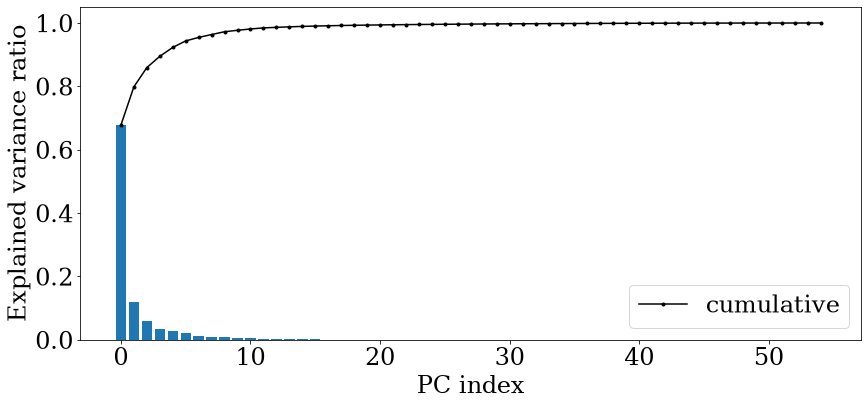

In [232]:
plt.figure(figsize=(14, 6))
plt.bar(np.arange(pca.n_components_), pca.explained_variance_ratio_)
plt.plot(np.arange(pca.n_components_), np.cumsum(pca.explained_variance_ratio_), 'k.-', label="cumulative")
plt.xlabel("PC index")
plt.ylabel("Explained variance ratio")
plt.legend()

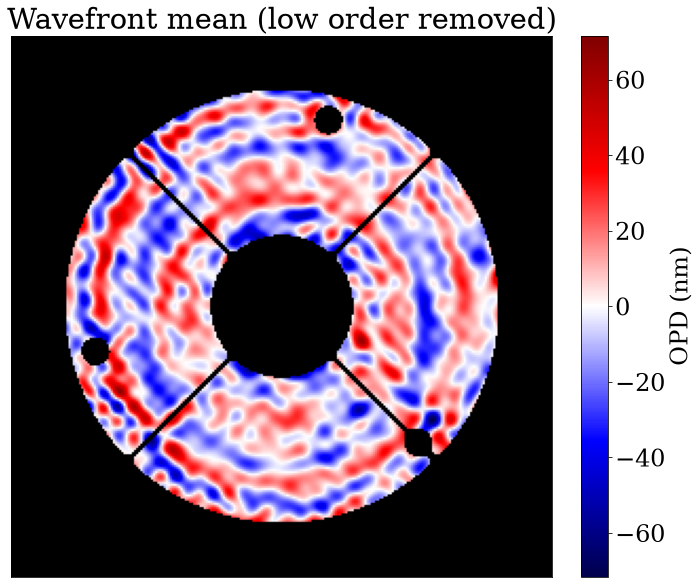

In [233]:
fig, ax = plt.subplots(figsize=(10, 8), layout="constrained")
show(ax, pca.mean_, "Wavefront mean (low order removed)", "OPD (nm)")

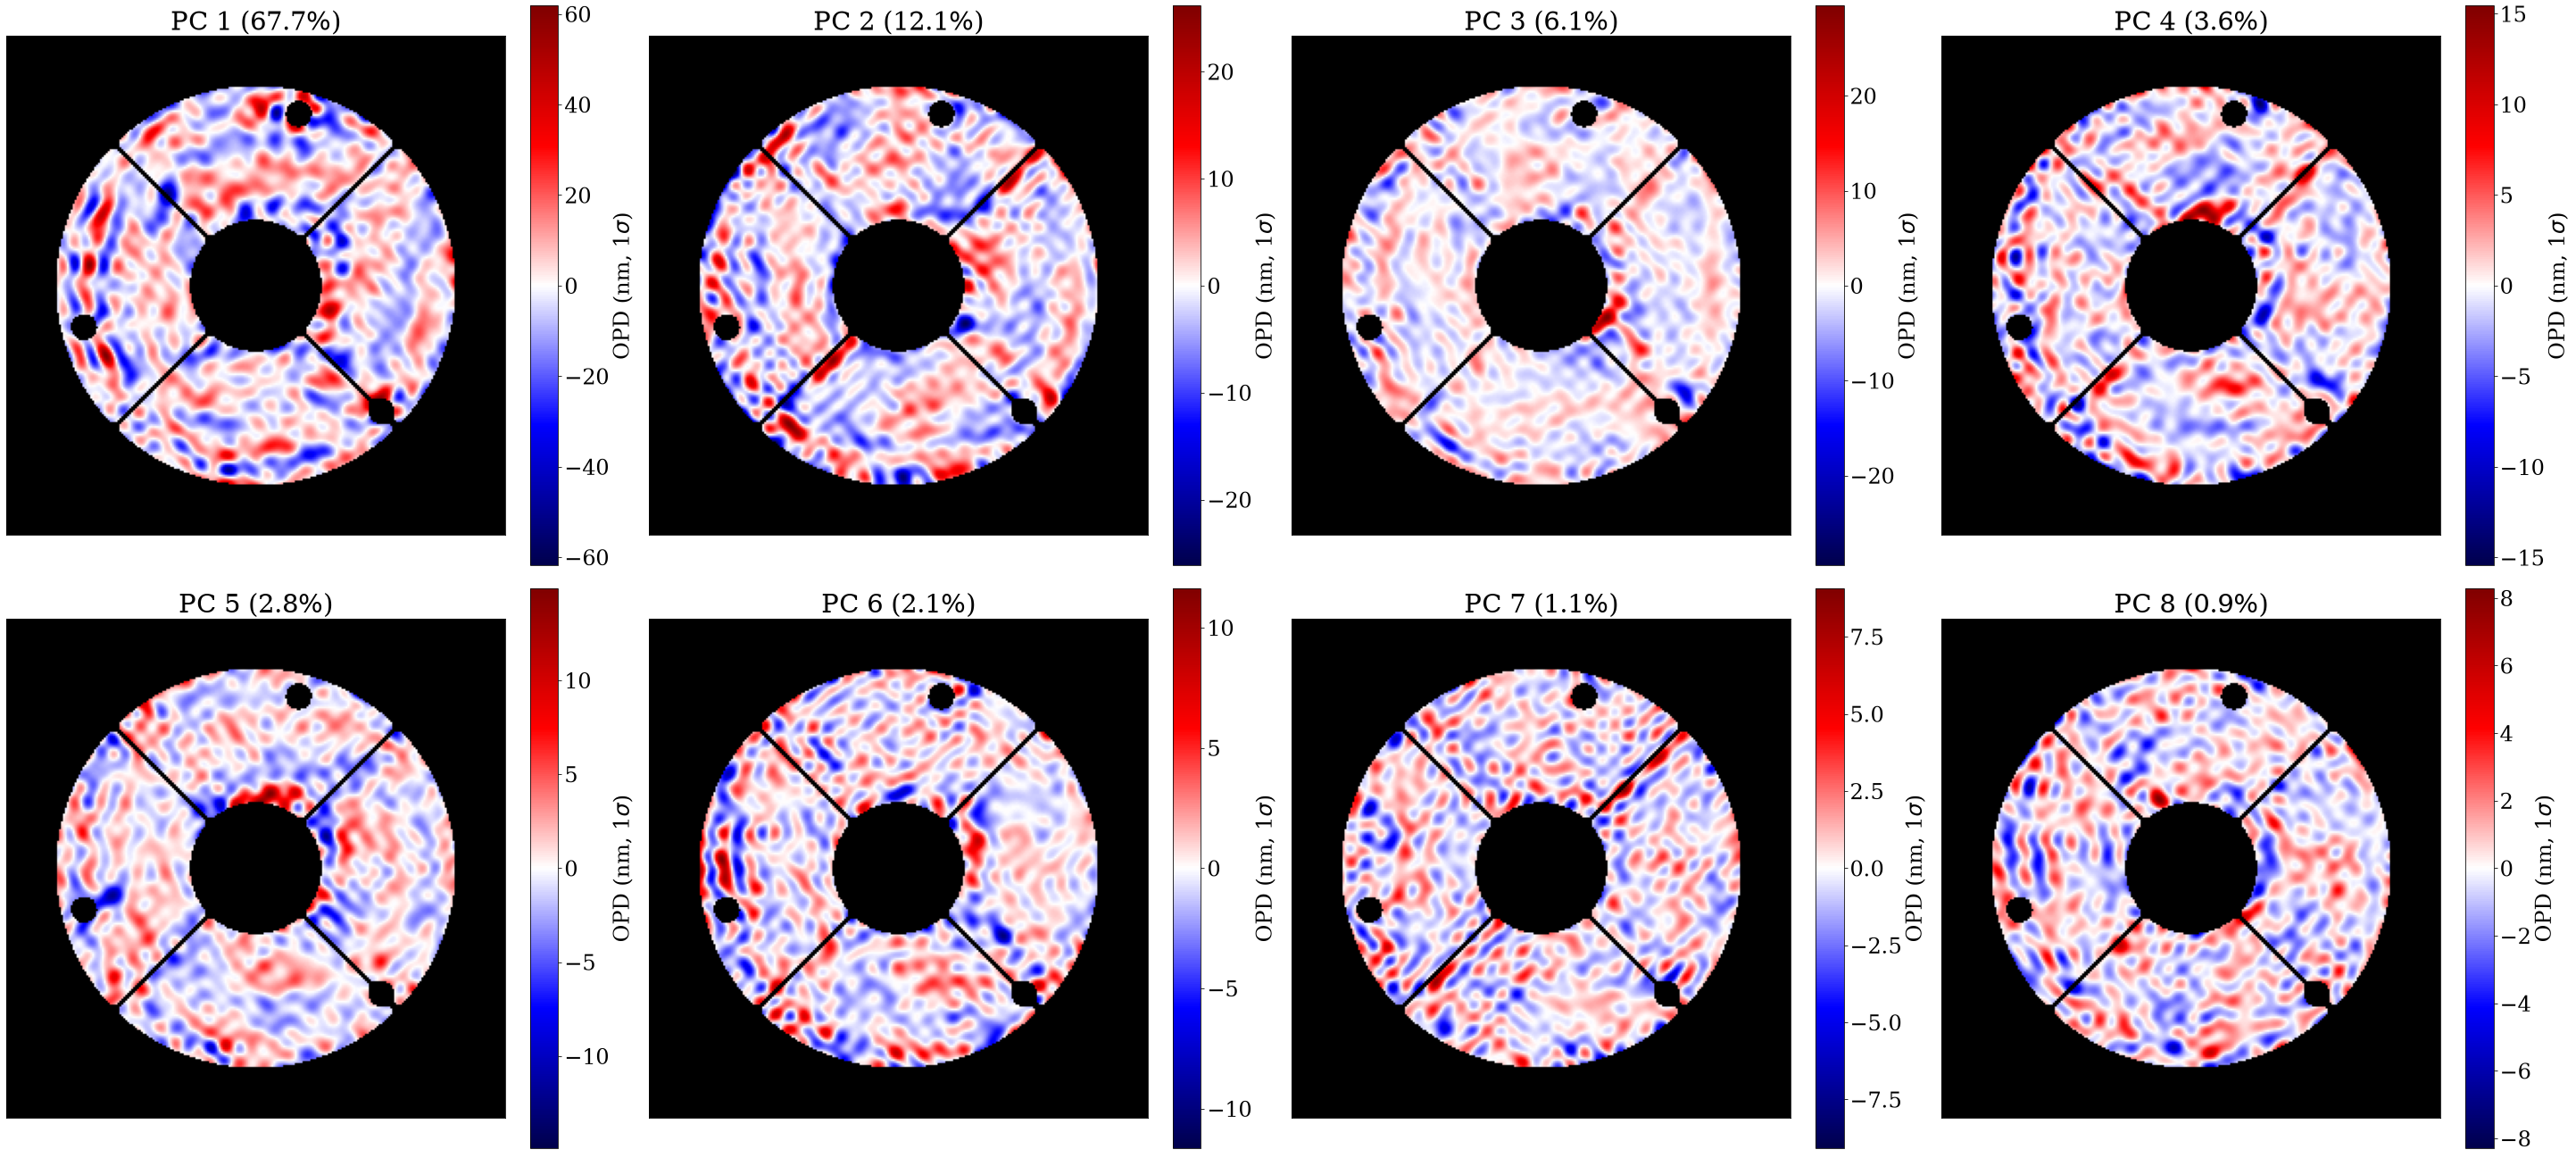

In [234]:
n_show = min(8, pca.n_components_)
fig, axs = plt.subplots(2, (n_show+1)//2, figsize=(10*((n_show+1)//2), 18), layout="constrained", squeeze=False)
for i, ax in enumerate(axs.flat[:n_show]):
    show(ax, pca.components_[i]*np.sqrt(pca.explained_variance_[i]),
         f"PC {i+1} ({100*pca.explained_variance_ratio_[i]:.1f}%)", "OPD (nm, 1$\\sigma$)")

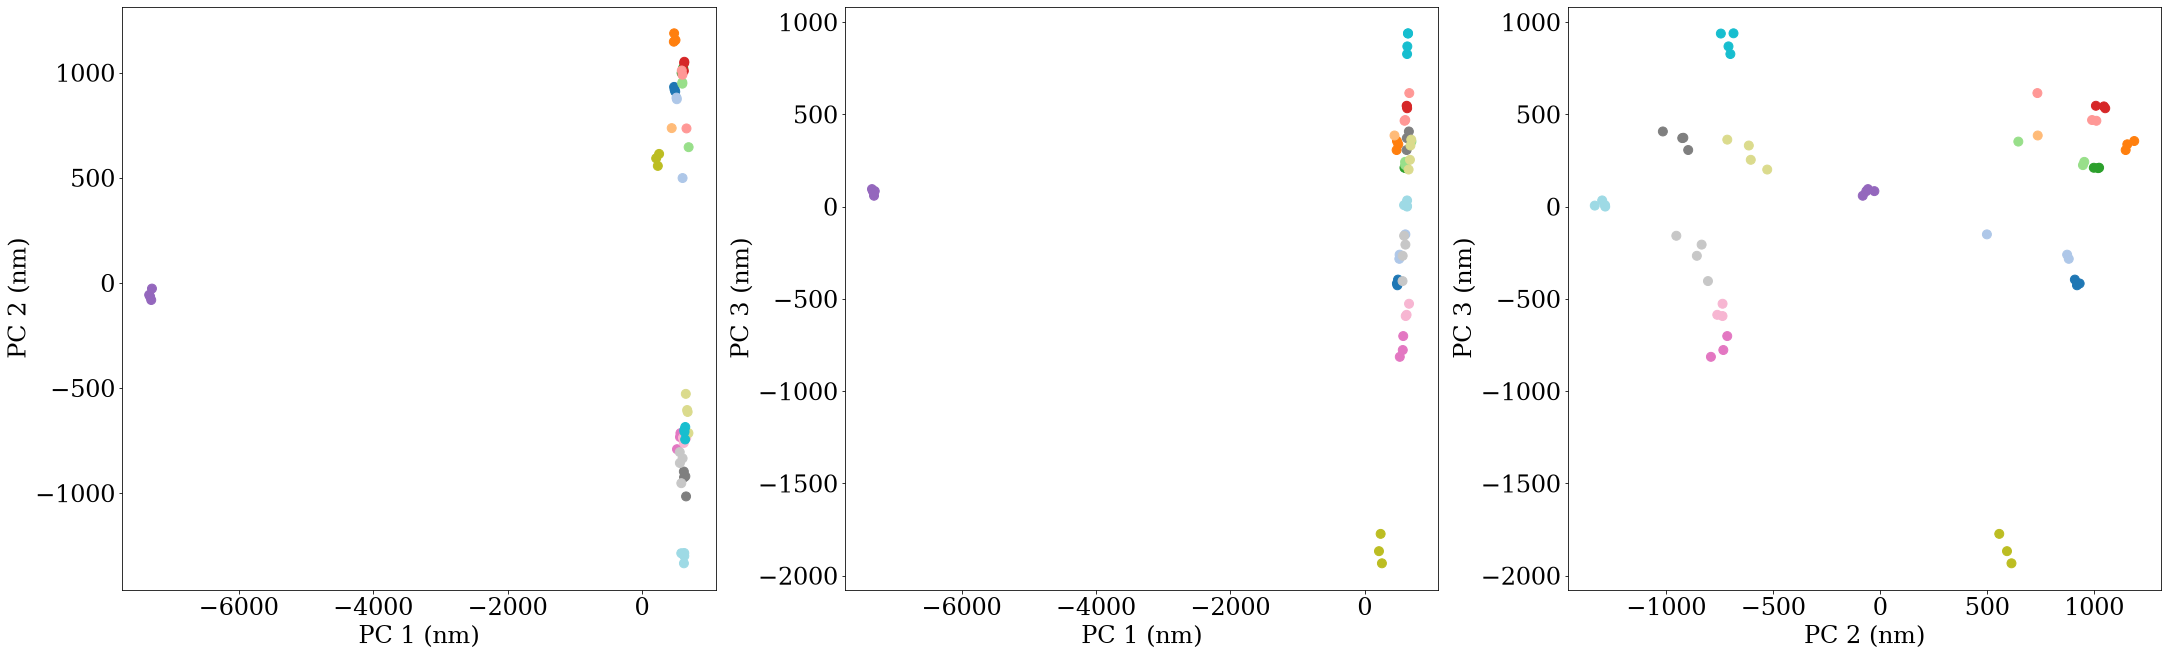

In [235]:
# Projections of each exposure onto the leading components, coloured by run
scores = pca.transform(numpy.asarray(wf_res))
run_of = numpy.array([i for i, _ in exposures])

fig, axs = plt.subplots(1, 3, figsize=(30, 9), layout="constrained")
for ax, (a, b) in zip(axs, [(0, 1), (0, 2), (1, 2)]):
    ax.scatter(scores[:, a], scores[:, b], c=run_of, cmap="tab20", s=80)
    ax.set(xlabel=f"PC {a+1} (nm)", ylabel=f"PC {b+1} (nm)")

### Save in the `turboklip.npz` format

`TransformedFourierBasis` expects `mean` (n_modes^2 Fourier coefficients, nm) and `modes` (unit-norm rows of Fourier coefficients). The PCA mean and components are pixel maps, so they are converted to Fourier coefficients by least squares on the support (piston excluded). Components are kept up to `var_frac` of the explained variance.

In [236]:
var_frac = 0.99
n_save = int(np.searchsorted(np.cumsum(pca.explained_variance_ratio_), var_frac) + 1)

# Fourier basis maps on the support pixels, one column per coefficient (piston column excluded)
eye = np.eye(n_modes**2)[1:]
B = jax.lax.map(lambda e: dlu.eval_fourier_basis(e.reshape((n_modes, n_modes)), *kernels)[support], eye, batch_size=64).T

maps = numpy.vstack([pca.mean_, pca.components_[:n_save]])
coeffs, *_ = np.linalg.lstsq(B, maps.T)
fit_frac = 1 - np.sum((B @ coeffs - maps.T)**2, axis=0)/np.sum(maps.T**2, axis=0)
print(f"Saving {n_save} components ({100*np.cumsum(pca.explained_variance_ratio_)[n_save-1]:.1f}% of variance)")
print("Fraction of each map captured by the Fourier fit (mean, then modes):", numpy.round(numpy.asarray(fit_frac), 3))

coeffs = np.concatenate([np.zeros((1, coeffs.shape[1])), coeffs]).T  # restore the piston coefficient
mean, modes = coeffs[0], coeffs[1:]
modes = modes/np.linalg.norm(modes, axis=1, keepdims=True)
np.savez("../data/wavefront_pca.npz", mean=mean, modes=modes)


Saving 16 components (99.0% of variance)
Fraction of each map captured by the Fourier fit (mean, then modes): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Amplitude PCA

`primary_amp` is fitted once per run; its coefficients are in units of `AMP_UNIT` of log-amplitude. Maps are shown as percent amplitude (100 x log-amplitude). PCA uses as many components as there are runs.

Amplitude RMS 11.07 %


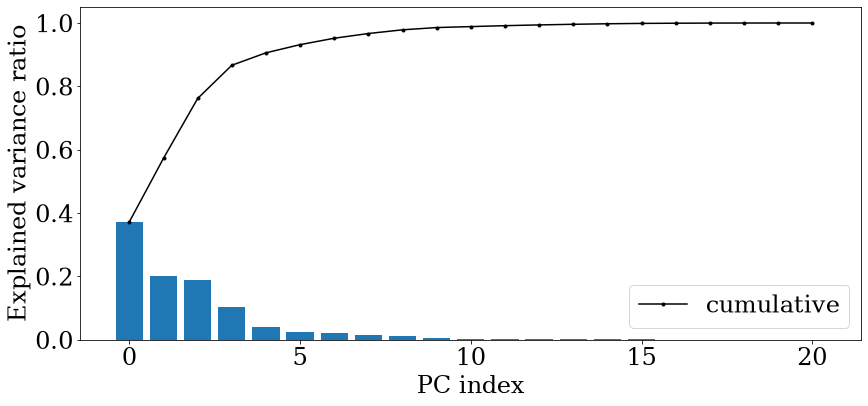

In [237]:
amp = np.stack([100*AMP_UNIT*fourier_map(np.asarray(p["primary_amp"]["global"]))[support] for p in params])
print(f"Amplitude RMS {np.sqrt(np.mean(amp**2)):.2f} %")

pca_amp = PCA(n_components=len(params))
pca_amp.fit(numpy.asarray(amp))

plt.figure(figsize=(14, 6))
plt.bar(np.arange(pca_amp.n_components_), pca_amp.explained_variance_ratio_)
plt.plot(np.arange(pca_amp.n_components_), np.cumsum(pca_amp.explained_variance_ratio_), 'k.-', label="cumulative")
plt.xlabel("PC index")
plt.ylabel("Explained variance ratio")
plt.legend()

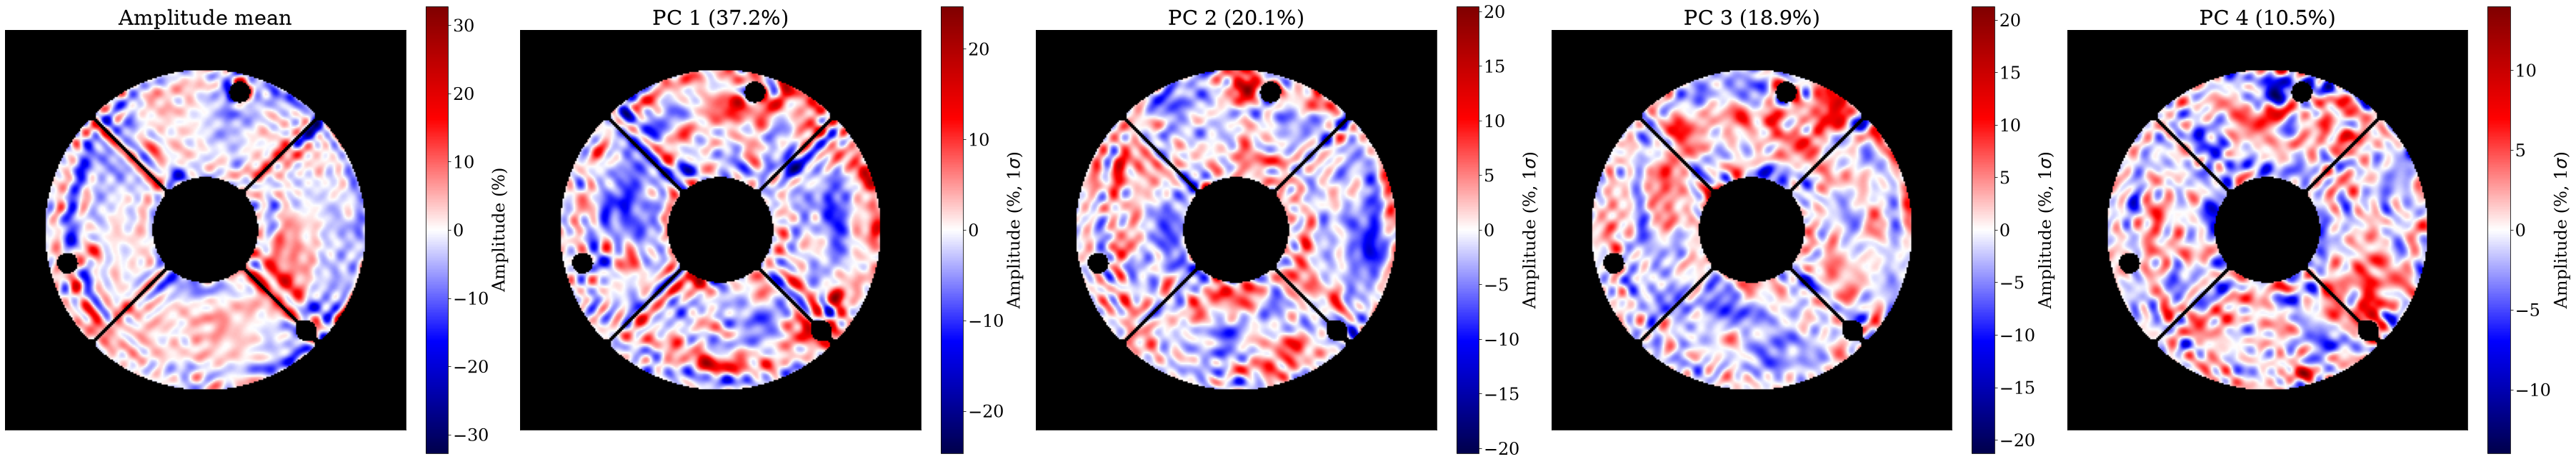

In [238]:
n_show = min(4, pca_amp.n_components_)
fig, axs = plt.subplots(1, n_show+1, figsize=(10*(n_show+1), 9), layout="constrained")
show(axs[0], pca_amp.mean_, "Amplitude mean", "Amplitude (%)")
for i, ax in enumerate(axs[1:]):
    show(ax, pca_amp.components_[i]*np.sqrt(pca_amp.explained_variance_[i]),
         f"PC {i+1} ({100*pca_amp.explained_variance_ratio_[i]:.1f}%)", "Amplitude (%, 1$\\sigma$)")

### Save in the `turboklip.npz` format

As for the wavefront, but in units of `AMP_UNIT` for `TransformedFourierAmplitude`. Only the leading `n_save_amp` components are kept, since there are only as many components as runs.

In [ ]:
n_save_amp = 5  # a few leading modes; more lets the fit absorb real structure

maps = numpy.vstack([pca_amp.mean_, pca_amp.components_[:n_save_amp]])/(100*AMP_UNIT)  # % -> AMP_UNIT
amp_coeffs, *_ = np.linalg.lstsq(B, maps.T)
fit_frac = 1 - np.sum((B @ amp_coeffs - maps.T)**2, axis=0)/np.sum(maps.T**2, axis=0)
print(f"Saving {n_save_amp} amplitude components ({100*np.cumsum(pca_amp.explained_variance_ratio_)[n_save_amp-1]:.1f}% of variance)")
print("Fraction of each map captured by the Fourier fit (mean, then modes):", numpy.round(numpy.asarray(fit_frac), 3))

amp_coeffs = np.concatenate([np.zeros((1, amp_coeffs.shape[1])), amp_coeffs]).T  # restore the piston coefficient
amp_mean, amp_modes = amp_coeffs[0], amp_coeffs[1:]
amp_modes = amp_modes/np.linalg.norm(amp_modes, axis=1, keepdims=True)
np.savez("../data/amplitude_pca.npz", mean=amp_mean, modes=amp_modes)

## Other parameters

Per-exposure parameters have one value per exposure; the rest are one per run. Vector parameters are split into components.

In [239]:
skip = {"primary_opd", "primary_amp", "spectrum"}

def columns(p, root):
    """Flatten the scalar/vector parameters of one exposure (per-exposure keys) or run (global keys)."""
    out = {}
    for k, v in p.items():
        if k in skip:
            continue
        if isinstance(v, dict):
            v = v[root] if root in v else v.get("global")
        v = numpy.atleast_1d(numpy.asarray(v))
        if k == "jitter":
            v = numpy.abs(v)
        if k == "primary_low":
            out["primary_low_rms"] = numpy.sqrt(numpy.mean(v**2))
            continue
        for j, x in enumerate(v):
            out[k if v.size == 1 else f"{k}[{j}]"] = x
    return out

table = [columns(params[i], root) for i, root in exposures]
names = list(table[0].keys())
values = {k: numpy.array([t[k] for t in table]) for k in names}

# Fit quality from the diagnostics
chi2 = numpy.array([next(e["all"]["chi2_red"] for e in diags[i]["exposures"] if e["rootname"] == root) for i, root in exposures])
values["chi2_red"] = chi2
names.append("chi2_red")

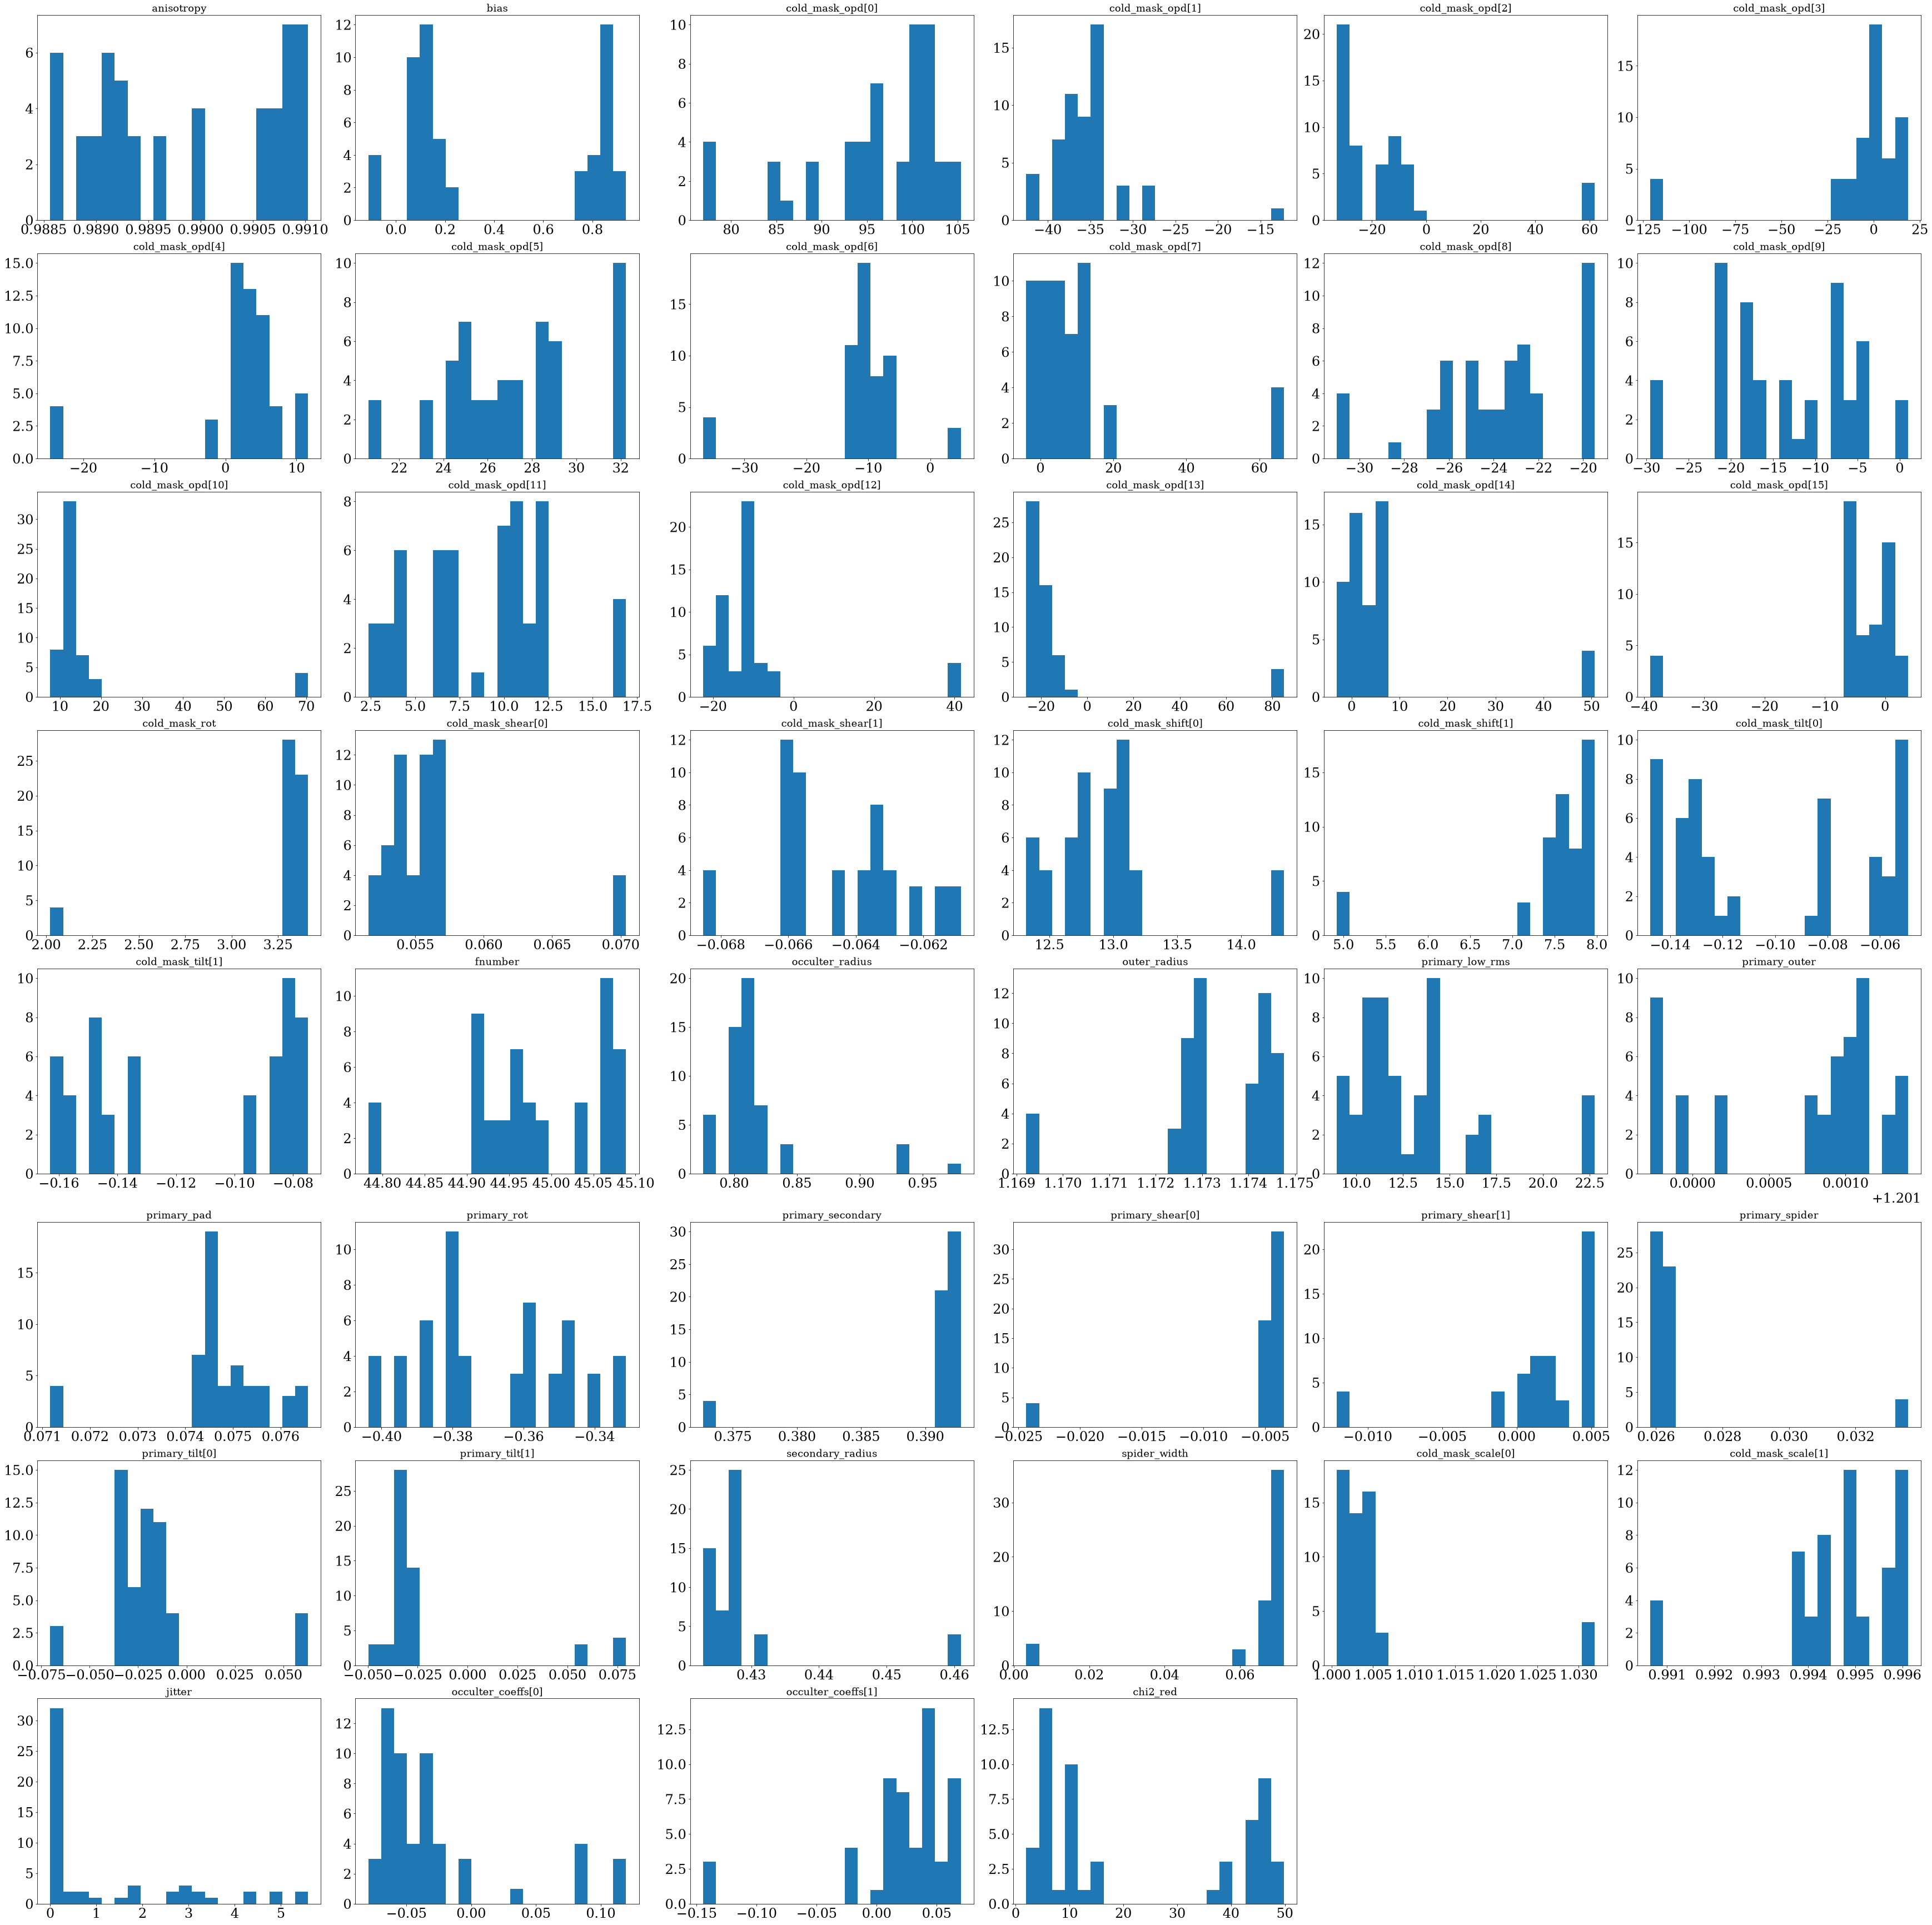

In [240]:
nx = 6
ny = -(-len(names)//nx)
fig, axs = plt.subplots(ny, nx, figsize=(8*nx, 6*ny), layout="constrained")
for ax, k in zip(axs.flat, names):
    ax.hist(values[k], bins=20)
    ax.set_title(k, fontsize=18)
for ax in axs.flat[len(names):]:
    ax.axis("off")

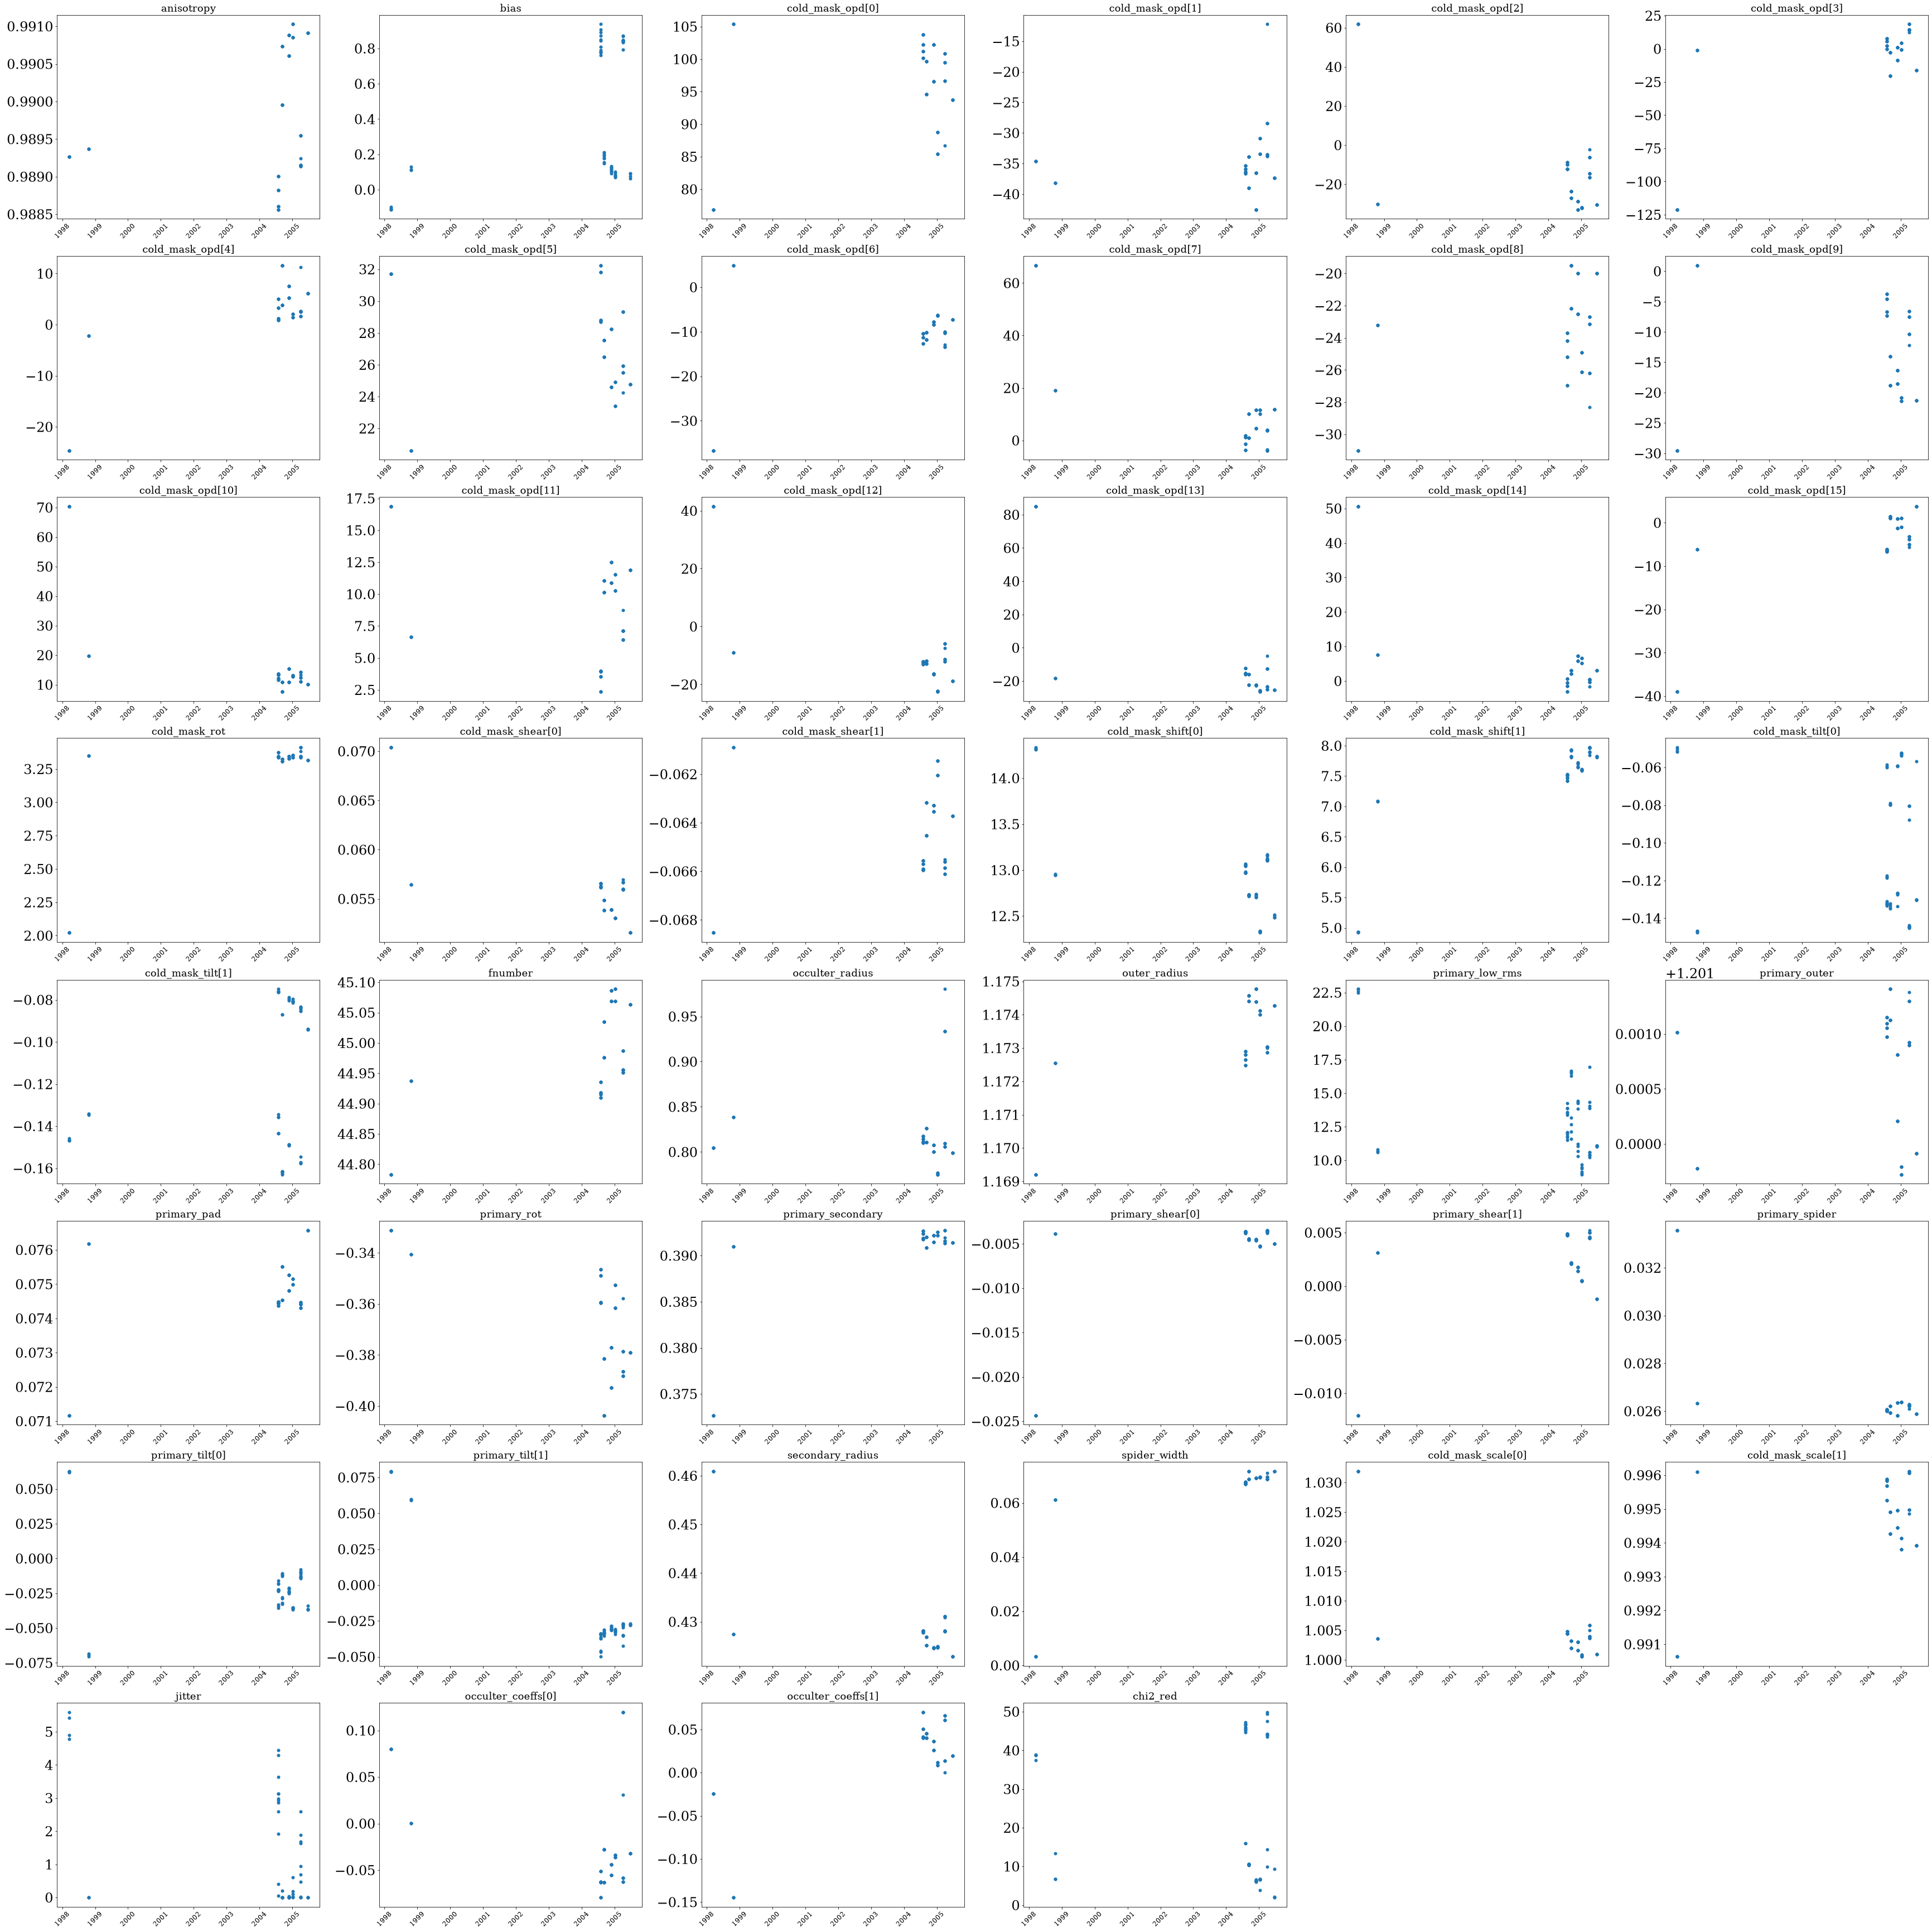

In [241]:
# The same parameters against observation date, to show any time trends
from datetime import datetime
dates = numpy.array([datetime.fromisoformat(diags[i]["date_obs"]) for i, _ in exposures])

fig, axs = plt.subplots(ny, nx, figsize=(8*nx, 6*ny), layout="constrained")
for ax, k in zip(axs.flat, names):
    ax.plot(dates, values[k], '.', ms=10)
    ax.set_title(k, fontsize=18)
    ax.tick_params(axis='x', labelrotation=45, labelsize=12)
for ax in axs.flat[len(names):]:
    ax.axis("off")

## Median optical parameters

Element-wise medians over runs of the global optical parameters, saved in the same format as `data/optical_params.npy` (a dict of values, with `{"global": value}` for parameters keyed globally), so they load the same way:
`params = params | np.load("../data/calibrator_optical_params.npy", allow_pickle=True)[()]`

Stage-1-only parameters (e.g. `cold_mask_shear`, `primary_shear`) are taken from each run's `intermediate-params.npy`. `primary_amp` is left out (it is described by the amplitude PCA above). `cold_mask_shift` is fitted per exposure here but keyed globally by default, so its median over exposures is saved under `"global"`.

In [242]:
global_keys = [k for k, v in params[0].items()
               if k not in ("primary_amp", "spectrum") and (not isinstance(v, dict) or list(v) == ["global"])]

def median(values):
    return np.median(np.stack([np.asarray(v) for v in values]), axis=0)

optical_params = {}
for k in global_keys:
    values = [p[k]["global"] if isinstance(p[k], dict) else p[k] for p in params]
    optical_params[k] = {"global": median(values)} if isinstance(params[0][k], dict) else median(values)
optical_params["cold_mask_shift"] = {"global": median([params[i]["cold_mask_shift"][root] for i, root in exposures])}

for k, v in optical_params.items():
    print(k, v)
np.save("../data/calibrator_optical_params.npy", optical_params)


anisotropy 0.9895490085587048
cold_mask_opd {'global': Array([ 97.73759485, -36.35517651, -14.49989937,  -0.39356669,
         3.2292401 ,  27.54181344, -10.08003316,   4.59939073,
       -24.19871949,  -7.47157234,  12.79148656,   8.73794453,
       -12.08470518, -15.96935037,   0.62448303,  -3.19289084],      dtype=float64)}
cold_mask_rot {'global': Array(3.33819108, dtype=float64)}
cold_mask_shear {'global': Array([ 0.05617597, -0.06552217], dtype=float64)}
fnumber 44.95509133206359
occulter_radius 0.8107123703841722
outer_radius 1.1728936344198544
primary_outer 1.201974357538905
primary_pad 0.07453524374912038
primary_rot {'global': Array(-0.36168226, dtype=float64)}
primary_secondary 0.3917730974997819
primary_shear {'global': Array([-0.00389851,  0.00217752], dtype=float64)}
primary_spider 0.02621485540006993
secondary_radius 0.42810859433953946
spider_width 0.0687890570187558
cold_mask_scale {'global': Array([1.00368735, 0.994971  ], dtype=float64)}
occulter_coeffs [-0.03354322 

## Median instrument state

The NICMOS coronagraph optics with the median optical parameters above, the median per-exposure pointing (`primary_tilt`, `cold_mask_tilt`), and the median (unprojected) `primary_opd` and `primary_amp`. Shows the pupil, cold mask, wavefront, amplitude and the resulting coronagraphic F160W PSF (flat spectrum through the filter).

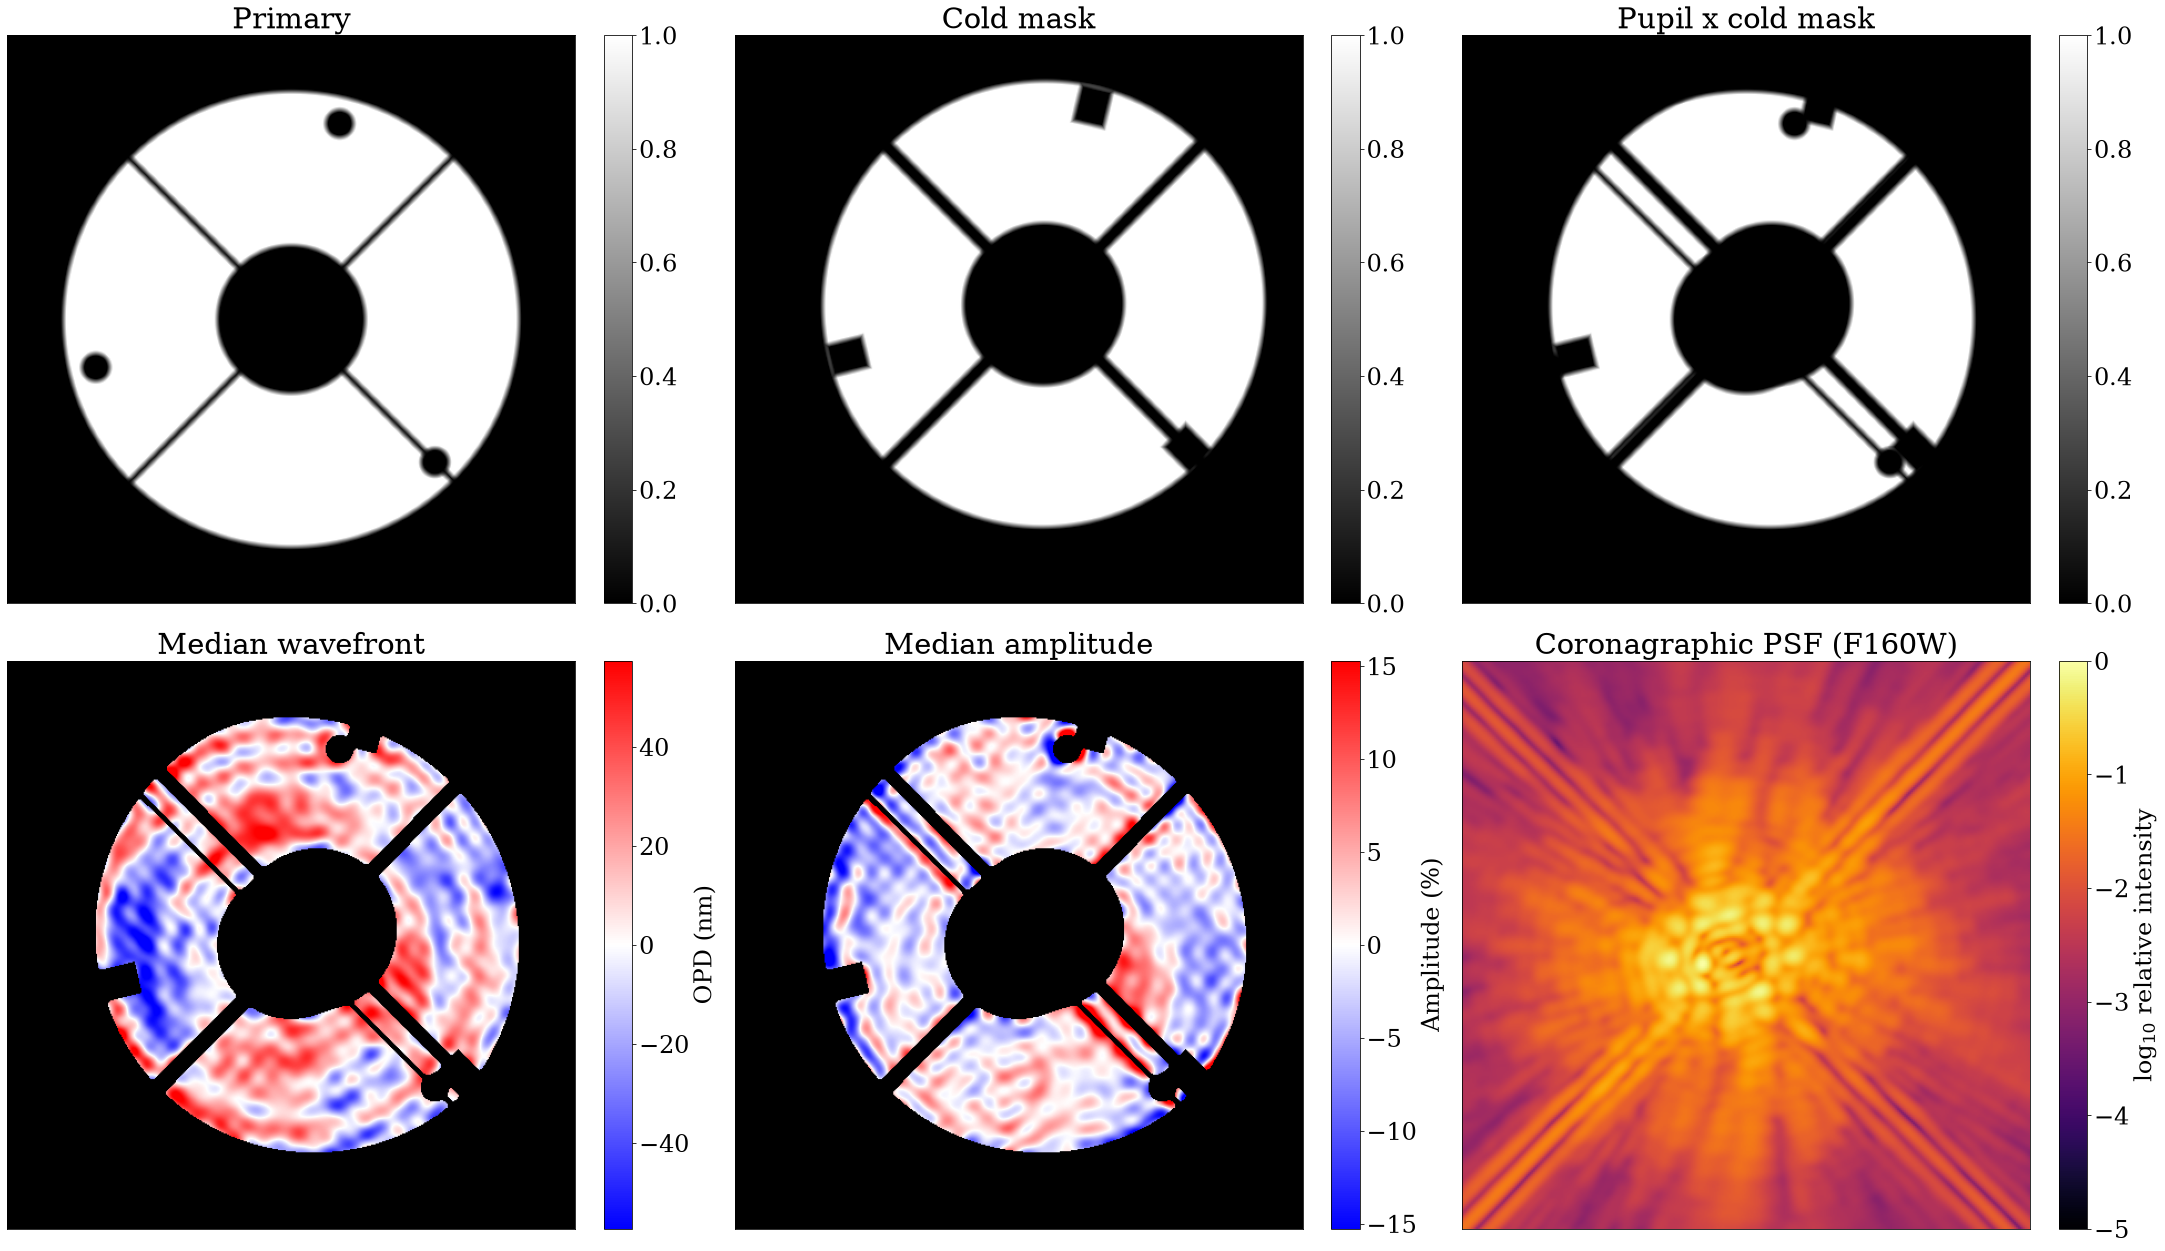

In [243]:
from plotting import _panel, _signed_panel  # underscore names are not covered by `import *`

per_exposure = lambda k: median([params[i][k][root] for i, root in exposures])
state = {k: (v["global"] if isinstance(v, dict) else v) for k, v in optical_params.items()}
state |= {k: per_exposure(k) for k in ["primary_tilt", "cold_mask_tilt", "primary_opd"]}
state["primary_amp"] = median([p["primary_amp"]["global"] for p in params])

# Apply the parameters as ModelFit.update_optics does
median_optics = NICMOSCoronagraph(512, 80, 4, n_modes=n_modes, n_zernikes=n_zernikes, amplitude=True)
coeffs = state["occulter_coeffs"]*dlu.arcsec2rad(0.3)*24*2.4
median_optics = median_optics.set(["occulter.layers.occulter.cc", "occulter.layers.occulter.ss"], [coeffs[::2], coeffs[1::2]])
for name, paths, transform in OPTICS_PARAMS:
    if name in state:
        for path in paths:
            median_optics = median_optics.set(path, transform(np.asarray(state[name])))

c = dlu.pixel_coords(512, median_optics.diameter)
primary = median_optics.primary.transmission(c, median_optics.diameter/512)
cold_mask = median_optics.cold_mask.transmission(c, median_optics.diameter/512)
beam = primary*cold_mask > .5
opd = 1e9*median_optics.primary_opd.eval_basis()
amp_pct = 100*(np.exp(median_optics.primary_amp.eval_basis()) - 1)

wv, inten = calc_throughput("F160W", 20)
psf = median_optics.model(dl.PointSource(wavelengths=wv, weights=inten))

fig, axs = plt.subplots(2, 3, figsize=(30, 19), layout="compressed")
_panel(axs[0, 0], primary, "Primary", "gray", 0, 1)
_panel(axs[0, 1], cold_mask, "Cold mask", "gray", 0, 1)
_panel(axs[0, 2], primary*cold_mask, "Pupil x cold mask", "gray", 0, 1)
_signed_panel(axs[1, 0], np.where(beam, opd, np.nan), "Median wavefront", 99, "OPD (nm)")
_signed_panel(axs[1, 1], np.where(beam, amp_pct, np.nan), "Median amplitude", 99, "Amplitude (%)")
_panel(axs[1, 2], np.log10(psf/psf.max()), "Coronagraphic PSF (F160W)", "inferno", -5, 0, "log$_{10}$ relative intensity")


## Save

The principal components as maps on the support pixels, plus the grid needed to rebuild them. Set `save = True` to write.

In [244]:
save = False
if save:
    numpy.savez("../data/calibrator_pca.npz",
                support=numpy.asarray(support), npix=npix, diameter=float(optics.diameter),
                opd_mean=pca.mean_, opd_modes=pca.components_, opd_variance=pca.explained_variance_,
                amp_mean=pca_amp.mean_, amp_modes=pca_amp.components_, amp_variance=pca_amp.explained_variance_,
                exposures=numpy.array([root for _, root in exposures]))